# Weather Data: Building a "Warming Stripes" Chart

This notebook builds current version of the [warming stripes (climate
stripes)](https://en.wikipedia.org/wiki/Warming_stripes) chart: a simple bar
of colored stripes, one per year, that turns from blue to red as the climate
warms. The idea was created by climate scientist Ed Hawkins at the
University of Reading (https://showyourstripes.info/s/globe/).

**Approaches for obtaining climate warns step by step:**
1. Download the list of German weather stations from the German
   Meteorological Service (DWD).
2. Pick one long-running station.
3. Download that station's monthly climate history.
4. Compute the average temperature for each year.
5. Turn those yearly averages into a warming-stripes chart.

**A note on network access:** every download step below is wrapped in a
`try/except`. If the DWD server can't be reached (e.g. no internet access,
or the server is temporarily down), the notebook automatically falls back
to a small bundled sample dataset so that it can still run every cell and
see a finished chart.

## Setup

In [1]:
# If a library below is missing, uncomment the matching line and run this cell.
#%pip install requests
#%pip install pandas
#%pip install matplotlib

In [2]:
import io
import zipfile
from urllib.request import urlopen

import matplotlib.pyplot as plt
import pandas as pd
import requests

## Step 1: Get the list of weather stations

The DWD publishes one text file listing every station, its ID, and the
date range it has data for. We need that file so we can later build the
download link for a *specific* station.

In [5]:
def stations_url(time_resolution="monthly"):
    # Build the URL of the station list for a given time resolution.
    # We keep this as a function (instead of hard-coding the URL) because
    # DWD hosts the same kind of file for daily/monthly/annual data - this
    # way we only change one word to switch resolutions.
    return (
        "https://opendata.dwd.de/climate_environment/CDC/observations_germany/"
        f"climate/{time_resolution}/kl/historical/KL_Monatswerte_Beschreibung_Stationen.txt"
    )


stations_url()

'https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/monthly/kl/historical/KL_Monatswerte_Beschreibung_Stationen.txt'

In [7]:
def fetch_stations():
    """
    Download and parse the DWD station list.

    Returns
    -------
    df : pandas.DataFrame
        Columns:
        id, start_date, end_date, lat, lon, name

    using_live_stations : bool
        True if live DWD data was successfully loaded.
    """

    url = stations_url()

    try:
        response = requests.get(url, timeout=15)
        response.raise_for_status()

        text = response.content.decode("latin-1")

        # ------------------------------------------------------------
        # DWD station files are fixed-width text files.
        # Instead of using whitespace splitting, parse each line
        # according to the character positions used by DWD.
        # ------------------------------------------------------------

        lines = text.splitlines()

        # Find the first actual data line.
        # A station record begins with a numeric station ID.
        # This avoids depending on exactly how many header/separator
        # lines the current DWD file contains.
        data_lines = []

        for line in lines:
            stripped = line.strip()

            if not stripped:
                continue

            # The first field should be a numeric station ID.
            first_field = stripped.split()[0]

            if first_field.isdigit():
                data_lines.append(line)

        if not data_lines:
            raise ValueError(
                "Could not find any station records in DWD file."
            )
        # Parse station records.
        # DWD station list layout
        # ID
        # From
        # bis
        # geoBreite
        # geoLaenge
        # Stationshoehe
        # Stationsname
        
        records = []

        for line in data_lines:

            parts = line.strip().split()

            # We need at least:
            # ID, start, end, lat, lon, height, name
            if len(parts) < 7:
                continue

            try:
                station_id = int(parts[0])
                start_date = int(parts[1])
                end_date = int(parts[2])
                lat = float(parts[3])
                lon = float(parts[4])
                height = float(parts[5])

                # Everything after the numeric fields is the name.
                name = " ".join(parts[6:]).strip()

                records.append(
                    {
                        "id": station_id,
                        "start_date": start_date,
                        "end_date": end_date,
                        "lat": lat,
                        "lon": lon,
                        "height": height,
                        "name": name,
                    }
                )

            except (ValueError, TypeError):
                # Ignore malformed/header lines.
                continue

        if not records:
            raise ValueError(
                "No valid stations were parsed from DWD file."
            )

        # ------------------------------------------------------------
        # Create dataframe.
        # ------------------------------------------------------------

        df = pd.DataFrame(records)

        # Keep only columns needed by the notebook.
        df = df[
            [
                "id",
                "start_date",
                "end_date",
                "lat",
                "lon",
                "name",
            ]
        ]

        df = df.reset_index(drop=True)

        print(f"Downloaded {len(df)} stations from DWD.")

        return df, True

    except (
        requests.RequestException,
        OSError,
        ValueError,
        TypeError,
    ) as err:

        print(
            f"Could not download/parse DWD station list ({err}). "
            "Using a small bundled sample instead."
        )

        # ------------------------------------------------------------
        # Offline fallback.
        # ------------------------------------------------------------

        sample = pd.DataFrame(
            {
                "id": [433, 3987],
                "start_date": [19510101, 18760101],
                "end_date": [20240101, 20240101],
                "lat": [52.4644, 52.5644],
                "lon": [13.4025, 13.3088],
                "name": [
                    "Berlin-Tempelhof",
                    "Berlin-Tegel",
                ],
            }
        )

        return sample, False


# ------------------------------------------------------------
# Load stations
# ------------------------------------------------------------

df_stations, using_live_stations = fetch_stations()

print()
print("Using live DWD stations:", using_live_stations)
print("Number of stations:", len(df_stations))

df_stations.head()


Downloaded 1226 stations from DWD.

Using live DWD stations: True
Number of stations: 1226


,id,start_date,end_date,lat,lon,name
0,1,19310101,19860630,478.0,47.8413,Aach Baden-Württemberg Frei
1,3,18510101,20110331,202.0,50.7827,Aachen Nordrhein-Westfalen Frei
2,44,19710301,20260831,44.0,52.9336,Großenkneten Niedersachsen Frei
3,52,19730101,20011231,46.0,53.6623,Ahrensburg-Wulfsdorf Schleswig-Holstein Frei
4,61,19750701,19780831,339.0,48.8443,Aiterhofen Bayern Frei


In [10]:
def fetch_stations():
    # Download and parse the DWD station list.
    # Why a try/except here: this is a live network call to an external
    # server. Network calls are the most likely thing to fail (no internet,
    # server hiccup, firewall) so we catch failures and fall back to a small
    # built-in sample instead of crashing the whole notebook.
    url = stations_url()
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        # The file is fixed-width text, not comma-separated, so we use a
        # regex of "one or more spaces" (\\s+) as the column separator.
        # skiprows=[1] drops the "----" separator line under the header.
        df = pd.read_csv(
            io.StringIO(response.content.decode("latin-1")),
            sep=r"\\s+",
            skiprows=[1],
            usecols=[0, 1, 2, 4, 5, 6],
            names=["id", "start_date", "end_date", "lat", "lon", "name"],
            header=None,
        )
        print(f"Downloaded {len(df)} stations from DWD.")
        return df, True

    except (requests.RequestException, OSError) as err:
        print(f"Could not reach DWD ({err}). Using a small bundled sample instead.")
        # A tiny hand-picked sample so the rest of the notebook still works
        # offline. Real station IDs/dates for two well-known stations.
        sample = pd.DataFrame(
            {
                "id": [433, 3987],
                "start_date": [19510101, 18760101],
                "end_date": [20240101, 20240101],
                "lat": [52.4644, 52.5644],
                "lon": [13.4025, 13.3088],
                "name": ["Berlin-Tempelhof", "Berlin-Tegel"],
            }
        )
        return sample, False


#df_stations, using_live_stations = fetch_stations()
df_stations.head()

,id,start_date,end_date,lat,lon,name
0,1,19310101,19860630,478.0,47.8413,Aach Baden-Württemberg Frei
1,3,18510101,20110331,202.0,50.7827,Aachen Nordrhein-Westfalen Frei
2,44,19710301,20260831,44.0,52.9336,Großenkneten Niedersachsen Frei
3,52,19730101,20011231,46.0,53.6623,Ahrensburg-Wulfsdorf Schleswig-Holstein Frei
4,61,19750701,19780831,339.0,48.8443,Aiterhofen Bayern Frei


## Step 2: Pick one weather station

We want a station with a *long* history, so the warming trend is easy to
see. Berlin-Tempelhof has data going back to 1951, so we search the
station list for it by name.

In [14]:
matches = df_stations[df_stations["name"].str.contains("Berlin", case=False)]
matches

,id,start_date,end_date,lat,lon,name
79,395,19480701,19531231,38.0,52.4167,Berlin-Adlershof Berlin Frei
80,399,19750101,20150531,36.0,52.5198,Berlin-Alexanderplatz Berlin Frei
81,400,18890101,20260831,60.0,52.6310,Berlin-Buch Berlin Frei
82,402,18300101,19621231,55.0,52.4564,Berlin-Dahlem (LFAG) Berlin Frei
83,403,17190101,20260831,51.0,52.4537,Berlin-Dahlem (FU) Berlin Frei
84,405,19510401,19541231,37.0,52.4500,Berlin-Friedrichshagen Berlin Frei
85,407,19580101,19780331,48.0,52.6461,Berlin-Frohnau Berlin Frei
86,408,18830101,19511130,35.0,52.5333,Berlin-Invalidenstraße Berlin Frei
87,410,19960601,20200531,33.0,52.4040,Berlin-Kaniswall Berlin Frei
88,416,19820701,19960930,47.0,52.4069,Berlin-Lichtenrade Berlin Frei


In [16]:
station = matches.iloc[0]
station

id                                     395
start_date                        19480701
end_date                          19531231
lat                                   38.0
lon                                52.4167
name          Berlin-Adlershof Berlin Frei
Name: 79, dtype: object

## Step 3: Download that station's monthly climate history

Each station's full history is stored in its own ZIP file. We build the
download URL from the station's ID and date range, then unzip and read
the data file inside it.

In [19]:
def station_data_url(station):
    # Build the ZIP download URL for one station's full history.
    station_id = int(station["id"])
    start_date = station["start_date"]
    end_date = station["end_date"]
    return (
        "https://opendata.dwd.de/climate_environment/CDC/observations_germany/"
        "climate/monthly/kl/historical/monatswerte_KL_"
        f"{station_id:05d}_{start_date}_{end_date}_hist.zip"
    )


station_data_url(station)

'https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/monthly/kl/historical/monatswerte_KL_00395_19480701_19531231_hist.zip'

In [20]:
def fetch_station_history(station):
    """
    Download, unzip, and parse one DWD station's monthly history.

    If the live download fails, a synthetic dataset is returned so the
    rest of the notebook can continue running.
    """

    url = station_data_url(station)

    try:
        # ------------------------------------------------------------
        # Download ZIP file
        # ------------------------------------------------------------
        with urlopen(url, timeout=15) as response:
            zip_bytes = response.read()

        # ------------------------------------------------------------
        # Open ZIP file
        # ------------------------------------------------------------
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:

            # Find the DWD data file.
            data_files = [
                name
                for name in zf.namelist()
                if name.startswith("produkt")
                and not name.endswith("/")
            ]

            if not data_files:
                raise ValueError(
                    "Could not find a 'produkt...' data file in the ZIP."
                )

            data_filename = data_files[0]

            # --------------------------------------------------------
            # Read CSV inside ZIP
            # --------------------------------------------------------
            with zf.open(data_filename) as f:
                df = pd.read_csv(
                    f,
                    sep=";",
                    encoding="latin-1",
                )

        # ------------------------------------------------------------
        # Clean column names
        # ------------------------------------------------------------
        df.columns = df.columns.str.strip()

        # ------------------------------------------------------------
        # Check that required columns exist
        # ------------------------------------------------------------
        required_columns = [
            "MESS_DATUM_BEGINN",
            "MO_TT",
        ]

        missing_columns = [
            col for col in required_columns
            if col not in df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"Missing required DWD columns: {missing_columns}"
            )

        # ------------------------------------------------------------
        # Parse date
        # ------------------------------------------------------------
        df["date"] = pd.to_datetime(
            df["MESS_DATUM_BEGINN"],
            format="%Y%m%d",
            errors="coerce",
        )

        # Remove rows with invalid dates.
        df = df.dropna(subset=["date"])

        # ------------------------------------------------------------
        # Extract year
        # ------------------------------------------------------------
        df["year"] = df["date"].dt.year

        # ------------------------------------------------------------
        # Rename temperature column
        # ------------------------------------------------------------
        df = df.rename(
            columns={
                "MO_TT": "mean_temp"
            }
        )

        # ------------------------------------------------------------
        # Convert temperature to numeric
        # ------------------------------------------------------------
        df["mean_temp"] = pd.to_numeric(
            df["mean_temp"],
            errors="coerce",
        )

        # DWD uses -999 / -999.0 for missing values.
        df["mean_temp"] = df["mean_temp"].replace(
            [-999, -999.0],
            pd.NA,
        )

        # ------------------------------------------------------------
        # Keep only the columns needed by the notebook
        # ------------------------------------------------------------
        df = df[
            [
                "date",
                "year",
                "mean_temp",
            ]
        ].copy()

        df = df.sort_values("date").reset_index(drop=True)

        # ------------------------------------------------------------
        # Sanity check
        # ------------------------------------------------------------
        if df.empty:
            raise ValueError(
                "DWD station file contained no usable records."
            )

        station_name = station.get("name", station.get("id", "unknown"))

        print(
            f"Downloaded {len(df)} monthly records for {station_name}."
        )

        return df, True

    except (
        requests.RequestException,
        urllib.error.URLError,
        OSError,
        zipfile.BadZipFile,
        StopIteration,
        ValueError,
        KeyError,
        pd.errors.ParserError,
    ) as err:

        print(
            f"Could not download station data ({err}). "
            "Using synthetic sample data instead."
        )

        # ------------------------------------------------------------
        # Synthetic fallback data
        # ------------------------------------------------------------
        import numpy as np

        rng = np.random.default_rng(seed=0)

        dates = pd.date_range(
            "1951-01-01",
            "2023-12-01",
            freq="MS",
        )

        years_elapsed = dates.year - 1951

        # Seasonal temperature cycle.
        seasonal = 9 * np.sin(
            (dates.month - 4) * 2 * np.pi / 12
        )

        # Long-term warming trend.
        trend = years_elapsed * 0.02

        # Random monthly noise.
        noise = rng.normal(
            0,
            1.2,
            size=len(dates),
        )

        mean_temp = (
            9
            + seasonal
            + trend
            + noise
        )

        df = pd.DataFrame(
            {
                "date": dates,
                "year": dates.year,
                "mean_temp": mean_temp,
            }
        )

        return df, False


# ------------------------------------------------------------
# Load history for the selected station
# ------------------------------------------------------------

df_history, using_live_history = fetch_station_history(station)

print()
print("Using live DWD history:", using_live_history)
print("Number of monthly records:", len(df_history))

df_history.head()


Downloaded 66 monthly records for Berlin-Adlershof Berlin Frei.

Using live DWD history: True
Number of monthly records: 66


,date,year,mean_temp
0,1948-07-01,1948,17.54
1,1948-08-01,1948,17.37
2,1948-09-01,1948,14.95
3,1948-10-01,1948,8.77
4,1948-11-01,1948,4.55


In [22]:
def fetch_station_history(station):
    """
    Download, unzip, and parse one DWD station's monthly history.

    If the live download fails, a synthetic dataset is returned so the
    rest of the notebook can continue running.
    """

    url = station_data_url(station)

    try:
        # ------------------------------------------------------------
        # Download ZIP file
        # ------------------------------------------------------------
        with urlopen(url, timeout=15) as response:
            zip_bytes = response.read()

        # ------------------------------------------------------------
        # Open ZIP file
        # ------------------------------------------------------------
        with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:

            # Find the DWD data file.
            data_files = [
                name
                for name in zf.namelist()
                if name.startswith("produkt")
                and not name.endswith("/")
            ]

            if not data_files:
                raise ValueError(
                    "Could not find a 'produkt...' data file in the ZIP."
                )

            data_filename = data_files[0]

            # --------------------------------------------------------
            # Read CSV inside ZIP
            # --------------------------------------------------------
            with zf.open(data_filename) as f:
                df = pd.read_csv(
                    f,
                    sep=";",
                    encoding="latin-1",
                )

        # ------------------------------------------------------------
        # Clean column names
        # ------------------------------------------------------------
        df.columns = df.columns.str.strip()

        # ------------------------------------------------------------
        # Check that required columns exist
        # ------------------------------------------------------------
        required_columns = [
            "MESS_DATUM_BEGINN",
            "MO_TT",
        ]

        missing_columns = [
            col for col in required_columns
            if col not in df.columns
        ]

        if missing_columns:
            raise ValueError(
                f"Missing required DWD columns: {missing_columns}"
            )

        # ------------------------------------------------------------
        # Parse date
        # ------------------------------------------------------------
        df["date"] = pd.to_datetime(
            df["MESS_DATUM_BEGINN"],
            format="%Y%m%d",
            errors="coerce",
        )

        # Remove rows with invalid dates.
        df = df.dropna(subset=["date"])

        # ------------------------------------------------------------
        # Extract year
        # ------------------------------------------------------------
        df["year"] = df["date"].dt.year

        # ------------------------------------------------------------
        # Rename temperature column
        # ------------------------------------------------------------
        df = df.rename(
            columns={
                "MO_TT": "mean_temp"
            }
        )

        # ------------------------------------------------------------
        # Convert temperature to numeric
        # ------------------------------------------------------------
        df["mean_temp"] = pd.to_numeric(
            df["mean_temp"],
            errors="coerce",
        )

        # DWD uses -999 / -999.0 for missing values.
        df["mean_temp"] = df["mean_temp"].replace(
            [-999, -999.0],
            pd.NA,
        )

        # ------------------------------------------------------------
        # Keep only the columns needed by the notebook
        # ------------------------------------------------------------
        df = df[
            [
                "date",
                "year",
                "mean_temp",
            ]
        ].copy()

        df = df.sort_values("date").reset_index(drop=True)

        # ------------------------------------------------------------
        # Sanity check
        # ------------------------------------------------------------
        if df.empty:
            raise ValueError(
                "DWD station file contained no usable records."
            )

        station_name = station.get("name", station.get("id", "unknown"))

        print(
            f"Downloaded {len(df)} monthly records for {station_name}."
        )

        return df, True

    except (
        requests.RequestException,
        urllib.error.URLError,
        OSError,
        zipfile.BadZipFile,
        StopIteration,
        ValueError,
        KeyError,
        pd.errors.ParserError,
    ) as err:

        print(
            f"Could not download station data ({err}). "
            "Using synthetic sample data instead."
        )

        # ------------------------------------------------------------
        # Synthetic fallback data
        # ------------------------------------------------------------
        import numpy as np

        rng = np.random.default_rng(seed=0)

        dates = pd.date_range(
            "1951-01-01",
            "2023-12-01",
            freq="MS",
        )

        years_elapsed = dates.year - 1951

        # Seasonal temperature cycle.
        seasonal = 9 * np.sin(
            (dates.month - 4) * 2 * np.pi / 12
        )

        # Long-term warming trend.
        trend = years_elapsed * 0.02

        # Random monthly noise.
        noise = rng.normal(
            0,
            1.2,
            size=len(dates),
        )

        mean_temp = (
            9
            + seasonal
            + trend
            + noise
        )

        df = pd.DataFrame(
            {
                "date": dates,
                "year": dates.year,
                "mean_temp": mean_temp,
            }
        )

        return df, False


# ------------------------------------------------------------
# Load history for the selected station
# ------------------------------------------------------------

df_history, using_live_history = fetch_station_history(station)

print()
print("Using live DWD history:", using_live_history)
print("Number of monthly records:", len(df_history))

df_history.head()


Downloaded 66 monthly records for Berlin-Adlershof Berlin Frei.

Using live DWD history: True
Number of monthly records: 66


,date,year,mean_temp
0,1948-07-01,1948,17.54
1,1948-08-01,1948,17.37
2,1948-09-01,1948,14.95
3,1948-10-01,1948,8.77
4,1948-11-01,1948,4.55


## Step 4: Compute the annual mean temperature

The warming stripes chart uses one value per *year*, not per month, so we
average the 12 monthly values for each year.

In [23]:
annual_mean = df_history.groupby("year")["mean_temp"].mean().dropna()
annual_mean.head()

year
1948    10.735000
1949     9.563333
1950     8.989167
1951     9.308333
1952     8.196667
Name: mean_temp, dtype: float64

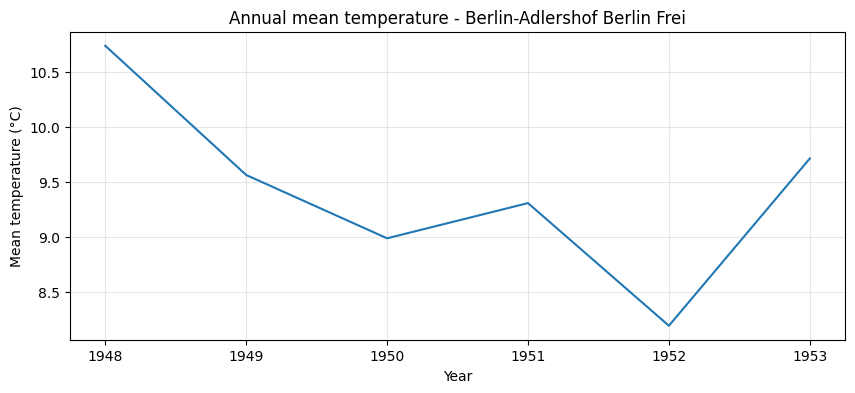

In [29]:
station_name = station.get("name", "Selected station")
plt.figure(figsize=(10, 4))
plt.plot(
    annual_mean.index,
    annual_mean.values
)
plt.title(f"Annual mean temperature - {station_name}")
plt.xlabel("Year")
plt.ylabel("Mean temperature (°C)")
plt.grid(alpha=0.3)
plt.show()

## Step 5: Turn it into a warming stripes chart

Each year becomes one vertical stripe. We color each stripe using a
blue-to-red colormap (`coolwarm`), where the color is based on how far
that year's temperature is from the overall average - cooler-than-average
years are blue, warmer-than-average years are red.

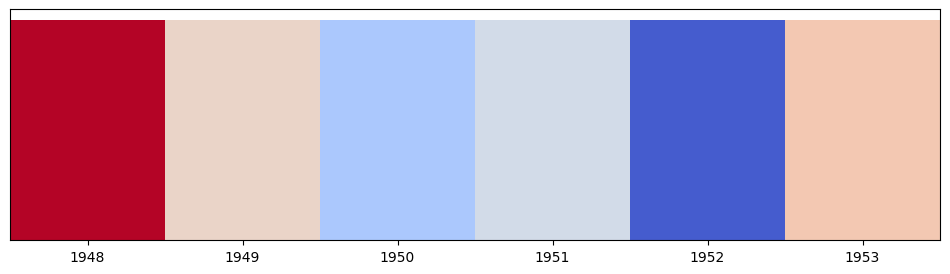

In [31]:
import numpy as np

# Center the color scale on the overall average so roughly half the
# stripes are blue and half are red.
overall_mean = annual_mean.mean()
temp_range = max(abs(annual_mean.max() - overall_mean), abs(annual_mean.min() - overall_mean))

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(
    annual_mean.index,
    height=1,
    width=1,
    color=plt.cm.coolwarm((annual_mean.values - overall_mean) / (2 * temp_range) + 0.5),
)
ax.set_xlim(annual_mean.index.min() - 0.5, annual_mean.index.max() + 0.5)
#ax.set_title(f"Warming stripes - {station["name"]}")
ax.set_yticks([])  # the height of each bar carries no meaning, only its color
plt.show()

## Wrap-up

- If the message above said "Downloaded ... from DWD", you're looking at
  real weather-station data.
- If it said "Using synthetic sample data instead", the notebook ran
  successfully but with generated stand-in data (this will happen in
  sandboxed environments without internet access). Re-run the notebook
  somewhere with internet access to see the real chart - no code changes
  needed.
- Try changing the station search in **Step 2** (e.g. search for a station
  near you) to build a warming stripes chart for a different place.